# Deep Hedging AI
### Vanilla Deep Hedging engine reference implementation with dynamic training update.

This is the main example notebook. It shows learning to hedge a vanilla call option (ATM by default), first in a Black & Scholes world with statistical drift, and secondly in a world where a second option can be traded.
The examples are not intended to be overly realistic.

In the Black & Scholes case we see that the hedge learned is _not_ the risk-neutral hedge. The notebook <tt>trainer-bs_nodrift.ipynb</tt> demonstrates that if the statistical drift is zero, and step size is sufficiently small (daily), then the Deep Hedging hedge approximates the risk-neutral hedge.

### Hans Buehler, June 30 2022


In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf



/Users/bartkoedijk/Bestanden/Thesis Code/deephedging/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
""" Slighly annoying: by default the SageMaker Python import directory does not include our git directory """
#!pip -q install cdxbasics "tensorflow>=2.11" "tensorflow_probability==0.19"
import os
p = os.getcwd()
dhn = "/deephedging/"
i = p.find(dhn)
my_path = None
if i!=-1:
    my_path = p[:i]
    import sys
    sys.path.append(my_path)
    print("SageMaker: added python path %s" % my_path)
else:
    print(sys.path)



SageMaker: added python path /Users/bartkoedijk/Bestanden/Thesis Code


In [3]:
import sys
import os

# This gets the path to the directory ABOVE 'deephedging'
# so that 'import deephedging.trainer' works correctly
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)



In [4]:
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import PPAWorld
from deephedging.objectives import oce_utility

from IPython.display import display, Markdown
from cdxbasics.config import Config

import numpy as np
from scipy.stats import skew
from scipy.optimize import minimize_scalar



Tensorflow version 2.16.2 running on 1 CPUs and 0 GPUs


In [5]:
config = Config()

config.world.samples = 100000
config.world.steps = 48

config.world.q1_target = 0.5
config.world.q2_target = 0.6
config.world.w1 = 0.91
config.world.w2 = 0.09
config.world.latent_model_type = "biegler_koenig_replication"
config.world.use_legacy_ppa_world = False
config.world.feature_model_type = "C"

config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 19
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "selu"
config.gym.agent.use_gru = False
config.gym.agent.features = ['time_left','forward_price', 'wind_info']
config.gym.agent.state.features = ['time_left','forward_price', 'wind_info']
config.gym.agent.init_delta.features = ['time_left','forward_price', 'wind_info']
config.gym.objective.y.features = ['time_left','forward_price', 'wind_info']

#old learning rate scheduler
l0 = 2e-5
alpha = 0.2
n_step = 4000
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=l0,
    decay_steps=n_step,
    decay_rate=alpha,
    staircase=True
)

config.trainer.train.optimizer.learning_rate = lr_schedule
config.trainer.train.optimizer.name = "adam"
config.trainer.train.batch_size = 2000
config.trainer.train.epochs = 800
config.trainer.train.early_stopping.active = True
# config.trainer.train.early_stopping.start_epoch = 150
# config.trainer.train.early_stopping.patience = 25
# config.trainer.train.early_stopping.min_delta = 1e-4
config.trainer.caching.mode = "off"
config.trainer.output_level = 'all'  # Disable plotting, keep text output
config.trainer.train.tf_verbose = 0

config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75


## Deep Hedging in a PPA World

<class 'cdxbasics.config.Config'>
Initializing training at 2026-05-14 10:11:54: gym with 2890 trainable weights compiled. Took 7s
Agent is using 968 weights: 961 for the main agent per step, 7 for initial delta.
 Features available per time step:     action, cost, delta, forward_price, pnl, time_left and wind_info
 Features used per time step:          forward_price, time_left and wind_info
 Features available for initial delta: cost, forward_price, time_left and wind_info
 Features used by initial delta:       forward_price, time_left and wind_info
Monetary utility cvar@19 is using 961 weights
 Features available: cost, forward_price, time_left and wind_info
 Features used:      forward_price, time_left and wind_info
Training monitor initialized. Took 0s
                                                                                                                                                                                                         


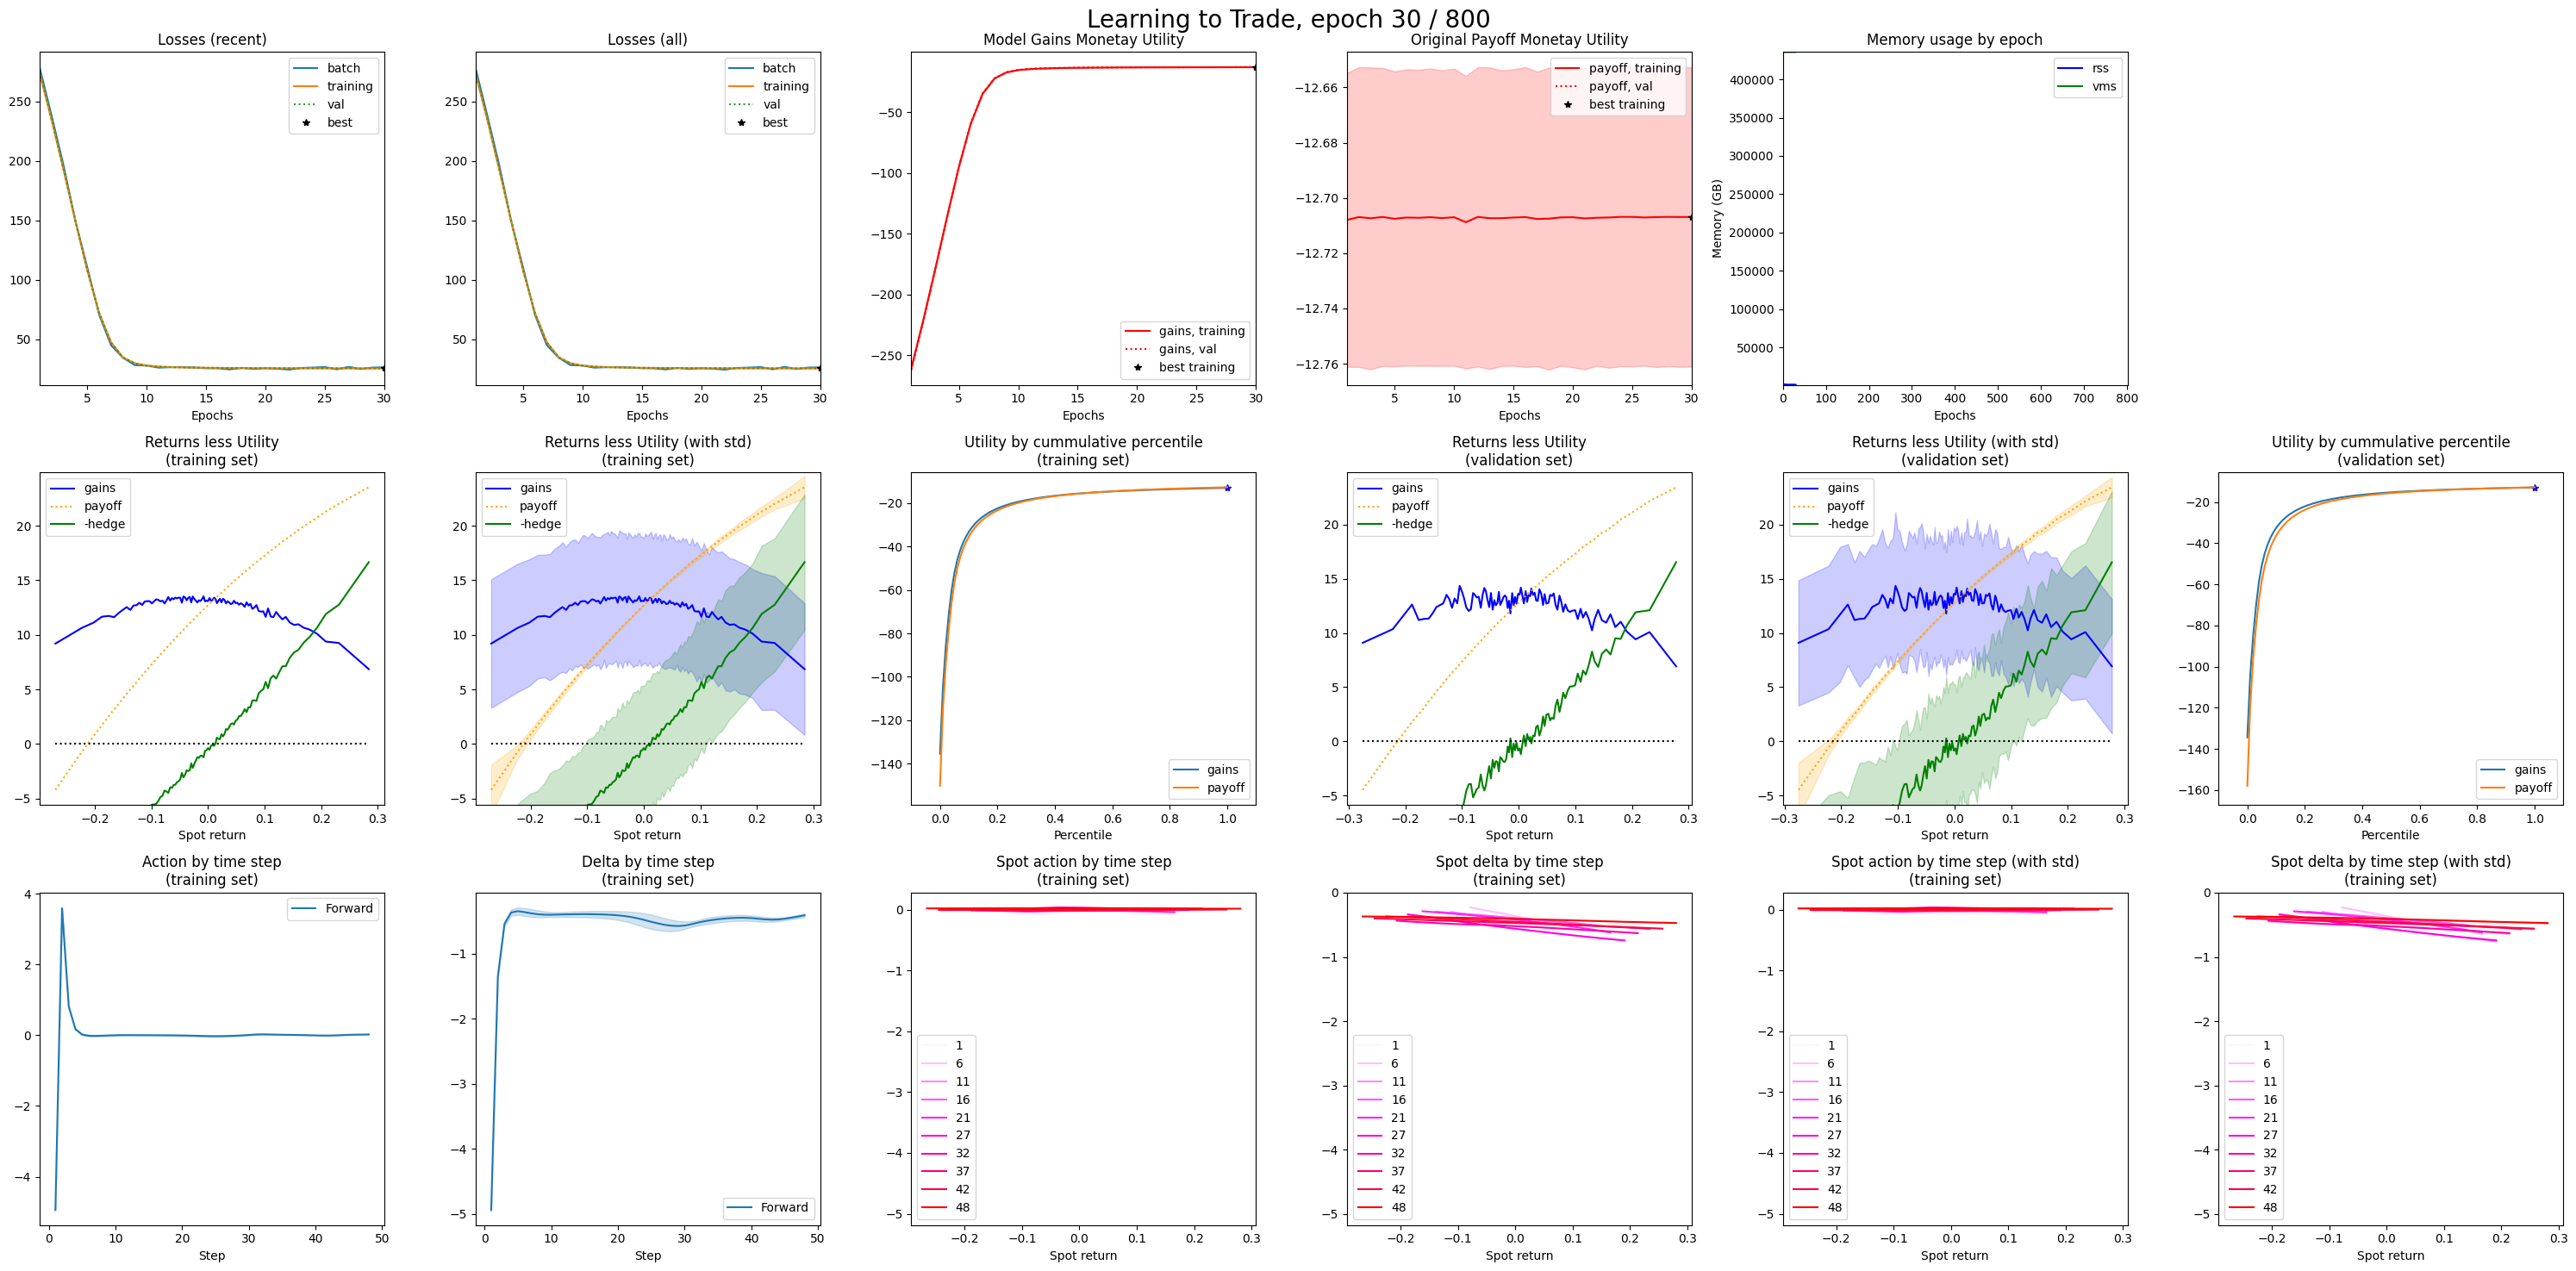

Training 32/800 epochs; 2890 weights; 100000 samples; 10000 validation samples batch size 2000 | initial loss 311.731 (4.32796), training 25.6501 (0.0729122), best 25.6816 (0.234468), batch 25.2082, val 25.6816 (0.234468); best epoch 32 | memory used: rss 1324.02M, vms 435806M | time elapsed 3:14; time per epoch 6s; estimated time remaining 1:17:45 | current time: 2026-05-14 10:15:09, estimated end time: 2026-05-14 11:32:55                        

In [ ]:
display(Markdown("## Deep Hedging in a PPA World"))
world = PPAWorld(config.world)
val_world = world.clone(samples=world.nSamples // 10)

gym = VanillaDeepHedgingGym(config.gym)
print(type(config.trainer))

train(gym=gym, world=world, val_world=val_world, config=Config(config.trainer))
r = gym(world.tf_data)

print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print(config.usage_report())
config.done()

optimal_delta = world.get_optimal_static_delta(lmbda=19.0)
static_delta_gains = world.get_static_pnl(optimal_delta)
print(f"Optimal static delta: {optimal_delta:.6f}")


In [8]:
import numpy as np
from scipy.stats import skew

print("Analysis of PnL used in PPA article:\n")
print(f"Mean payoff: {np.mean(r['payoff']):.6f}")
print(f"Min utility: {np.min(r['utility']):.6f}")
print(f"Min unhedged utility: {np.min(r['utility0']):.6f}")
print(f"Mean hedging pnl: {np.mean(r['pnl']):.6f}")  
print(f"Mean cost: {np.mean(r['cost']):.6f}")
print(f"Mean total gains: {np.mean(r['payoff'] + r['pnl'] - r['cost']):.6f}\n")


hedged_gains = r['payoff'] + r['pnl'] - r['cost']
unhedged_gains = r['payoff']

def compute_stats(gains, label):
    print(f"\n{label}:")
    print(f"    Mean:{np.mean(gains):.6f}")
    print(f"    Std Dev: {np.std(gains):.6f}")
    print(f"    Variance: {np.var(gains):.6f}")
    print(f"    Skewness: {skew(gains):.6f}")
    print(f"    1% ES: {np.mean(gains[gains <= np.percentile(gains,1)]):.6f}")
    print(f"    5% ES: {np.mean(gains[gains <= np.percentile(gains, 5)]):.6f}")
    print(f"    30% ES: {np.mean(gains[gains <= np.percentile(gains, 30)]):.6f}")

compute_stats(hedged_gains, "Hedged gains")
compute_stats(unhedged_gains, "Unhedged gains")
compute_stats(static_delta_gains, "static delta hedge")

Analysis of PnL used in PPA article:

Mean payoff: -0.506161
Min utility: -28.624111
Min unhedged utility: -371.965820
Mean hedging pnl: 0.024598
Mean cost: 0.000000
Mean total gains: -0.481563


Hedged gains:
    Mean:-0.481563
    Std Dev: 0.254524
    Variance: 0.064783
    Skewness: 1.038699
    1% ES: -1.122715
    5% ES: -0.945098
    30% ES: -0.738207

Unhedged gains:
    Mean:-0.506161
    Std Dev: 5.277174
    Variance: 27.848558
    Skewness: -0.465018
    1% ES: -16.928503
    5% ES: -12.706870
    30% ES: -6.847706

static delta hedge:
    Mean:-0.483995
    Std Dev: 0.701634
    Variance: 0.492290
    Skewness: -2.676421
    1% ES: -4.112100
    5% ES: -2.746745
    30% ES: -1.291442


## Congestion Experiment

This block is the cleaned one-country congestion experiment. It uses the new transparent `PPAWorld` setup:

- price is driven by uncurtailed national wind,
- PPA volume is delivered volume after congestion,
- A sees aggregate wind, B sees aggregate wind plus dispersion, and C sees site-level forecasts.

Run the cells in order: calibration, preflight, oracle gate, neural training, trained-mechanism plot.


In [5]:

from deephedging.base import npCast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

EXPERIMENT_PRESET = "bk_10_site_spatial_volume_risk_basis"

SPATIAL_VOLUME_RISK_WORLD = {
    "latent_model_type": EXPERIMENT_PRESET,
    "steps": 48,
    "synthetic_num_sites": 10,
    "synthetic_minimal_congested_sites": 5,
    "synthetic_target": 0.5,
    "synthetic_mean_reversion": 0.02,
    "synthetic_vol": 0.35,
    "synthetic_two_region_within_corr": 0.90,
    "synthetic_two_region_cross_corr": -0.25,
    "f_0_T": 100.0,
    "ppa_strike": 100.0,
    "mean_rev_p": 0.5 / 24.0,
    "vol_p": 0.25 / np.sqrt(365.0 * 24.0),
    "use_transaction_cost": False,
}

TRADE_BOUND = 5.0
INVENTORY_BOUND = 1.5
CALIBRATION_SEED = 2312414312
CALIBRATION_SAMPLES = 30000


def configure_spatial_volume_risk_world(cfg, *, samples, seed, feature_model_type="C", l_max=np.inf):
    cfg.samples = int(samples)
    cfg.seed = int(seed)
    cfg.l_max = float(l_max)
    cfg.feature_model_type = feature_model_type
    cfg.use_legacy_ppa_world = False
    cfg.lbnd_trade = -TRADE_BOUND
    cfg.ubnd_trade = TRADE_BOUND
    cfg.lbnd_a = -INVENTORY_BOUND
    cfg.ubnd_a = INVENTORY_BOUND
    for key, value in SPATIAL_VOLUME_RISK_WORLD.items():
        setattr(cfg, key, value)
    return cfg


def build_spatial_volume_risk_world(samples, seed, *, feature_model_type="C", l_max=np.inf):
    cfg = Config()
    configure_spatial_volume_risk_world(
        cfg.world,
        samples=samples,
        seed=seed,
        feature_model_type=feature_model_type,
        l_max=l_max,
    )
    return PPAWorld(cfg.world)


def expected_shortfall(gains, alpha=0.05):
    x = np.asarray(gains, dtype=float).reshape(-1)
    threshold = np.quantile(x, alpha)
    return float(np.mean(x[x <= threshold]))


def linear_slope(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3 or np.std(x[ok]) < 1e-12:
        return np.nan
    return float(np.polyfit(x[ok], y[ok], 1)[0])


def middle_fraction_mask(x, fraction=0.30):
    x = np.asarray(x, dtype=float).reshape(-1)
    lo = 0.5 - fraction / 2.0
    hi = 0.5 + fraction / 2.0
    return (x >= np.quantile(x, lo)) & (x <= np.quantile(x, hi))


def binned_mean(x, y, bins):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    idx = np.clip(np.digitize(x, bins) - 1, 0, len(bins) - 2)
    return np.array([np.mean(y[idx == b]) if np.any(idx == b) else np.nan for b in range(len(bins) - 1)])


def mechanism_arrays(world):
    q_total = np.asarray(world.details.q_total_realized, dtype=float)
    q_cong = np.asarray(world.details.q_cong, dtype=float)
    q_unc = np.asarray(world.details.q_unc, dtype=float)
    q_delivered = np.asarray(world.details.q_tilde, dtype=float)
    q_potential = q_cong + q_unc
    curtailment_loss = q_potential - q_delivered
    q_cong_share = np.divide(q_cong, q_total, out=np.zeros_like(q_cong), where=q_total > 1e-12)
    delivered_ratio = np.divide(q_delivered, q_potential, out=np.ones_like(q_delivered), where=q_potential > 1e-12)
    return {
        "q_total": q_total,
        "q_cong": q_cong,
        "q_unc": q_unc,
        "q_delivered": q_delivered,
        "q_potential": q_potential,
        "curtailment_loss": curtailment_loss,
        "q_cong_share": q_cong_share,
        "delivered_ratio": delivered_ratio,
    }


def print_gain_stats(gains, label):
    gains = np.asarray(gains, dtype=float).reshape(-1)
    print(f"\n{label}:")
    print(f"    Mean: {np.mean(gains):.6f}")
    print(f"    Std Dev: {np.std(gains):.6f}")
    print(f"    Variance: {np.var(gains):.6f}")
    print(f"    Skewness: {skew(gains):.6f}")
    print(f"    1% ES: {expected_shortfall(gains, 0.01):.6f}")
    print(f"    5% ES: {expected_shortfall(gains, 0.05):.6f}")
    print(f"    30% ES: {expected_shortfall(gains, 0.30):.6f}")

print(f"Active spatial volume-risk preset: {EXPERIMENT_PRESET}")


Active spatial volume-risk preset: bk_10_site_spatial_volume_risk_basis


### Calibration And Preflight

This calibrates `L_max` from the simulated congested-region volume and checks the physical mechanism before neural training. The main x-axis is `Q_cong / Q_total`, matching the congestion-volume-risk sketch.


,case,decision_step,l_max,curtailment_frequency,n_paths_matched_qagg,delivered_ratio_slope,delivered_volume_slope,potential_volume_slope,curtailment_loss_slope,mechanism_pass
0,no_curtailment,18,inf,0.000000,9000,1.127268e-09,0.001006,0.001006,-4.308123e-10,False
1,no_curtailment,38,inf,0.000000,9000,5.924002e-10,0.003087,0.003087,-8.679128e-11,False
2,no_curtailment,42,inf,0.000000,9000,-3.324271e-11,-0.003592,-0.003592,1.753765e-10,True
3,no_curtailment,45,inf,0.000000,9000,-9.851780e-10,-0.002802,-0.002802,5.997020e-10,True
4,no_curtailment,47,inf,0.000000,9000,-1.674470e-09,0.000242,0.000242,8.864760e-10,False
5,p70,18,0.342099,0.300000,9000,-1.626230e-01,-0.086783,0.001006,8.778820e-02,True
6,p70,38,0.342099,0.300000,9000,-1.799715e-01,-0.090978,0.003087,9.406550e-02,True
7,p70,42,0.342099,0.300000,9000,-1.907153e-01,-0.101958,-0.003592,9.836576e-02,True
8,p70,45,0.342099,0.300000,9000,-1.997391e-01,-0.104564,-0.002802,1.017621e-01,True
9,p70,47,0.342099,0.300000,9000,-2.088977e-01,-0.105523,0.000242,1.057641e-01,True


,case,l_max,curtailment_frequency,mechanism_pass_any_step,best_delivered_volume_slope,best_curtailment_loss_slope
0,no_curtailment,inf,0.000000,True,-0.003592,8.864760e-10
1,p60,0.296477,0.397000,True,-0.170236,1.704771e-01
2,p65,0.319469,0.347767,True,-0.136576,1.368174e-01
3,p70,0.342099,0.300000,True,-0.105523,1.057641e-01


Preflight passed: True


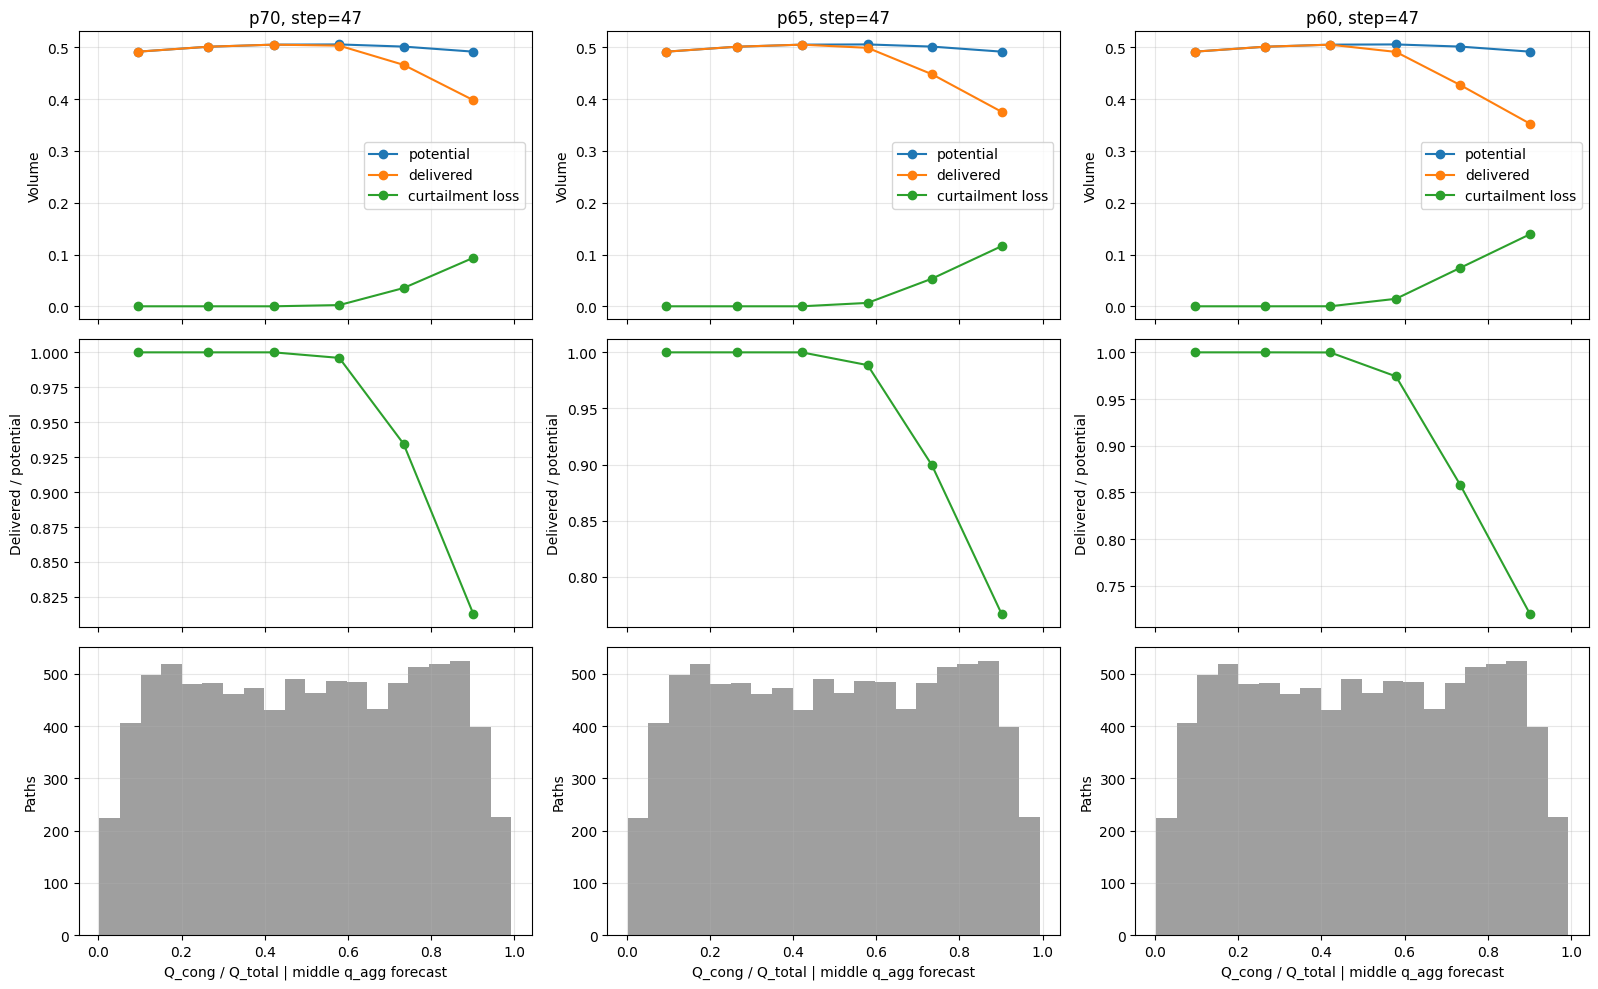

In [6]:

calibration_world = build_spatial_volume_risk_world(
    CALIBRATION_SAMPLES,
    CALIBRATION_SEED,
    feature_model_type="C",
    l_max=np.inf,
)
q_cong_calibration = np.asarray(calibration_world.details.q_cong, dtype=float)

L_MAX_BY_CASE = {
    "no_curtailment": np.inf,
    "p70": float(np.quantile(q_cong_calibration, 0.70)),
    "p65": float(np.quantile(q_cong_calibration, 0.65)),
    "p60": float(np.quantile(q_cong_calibration, 0.60)),
}
PREFLIGHT_CASES = ["no_curtailment", "p70", "p65", "p60"]
PREFLIGHT_STEPS = [18, 38, 42, 45, 47]

preflight_rows = []
preflight_worlds = {}
for case_name in PREFLIGHT_CASES:
    world_pf = build_spatial_volume_risk_world(
        samples=30000,
        seed=202604081,
        feature_model_type="C",
        l_max=L_MAX_BY_CASE[case_name],
    )
    preflight_worlds[case_name] = world_pf
    arr = mechanism_arrays(world_pf)
    curtailment_frequency = float(np.mean(arr["q_cong"] > L_MAX_BY_CASE[case_name])) if np.isfinite(L_MAX_BY_CASE[case_name]) else 0.0
    for step in PREFLIGHT_STEPS:
        q_agg_forecast = np.asarray(world_pf.details.q_agg_forecast)[:, step]
        same_qagg = middle_fraction_mask(q_agg_forecast, fraction=0.30)
        x = arr["q_cong_share"][same_qagg]
        preflight_rows.append({
            "case": case_name,
            "decision_step": step,
            "l_max": L_MAX_BY_CASE[case_name],
            "curtailment_frequency": curtailment_frequency,
            "n_paths_matched_qagg": int(np.sum(same_qagg)),
            "delivered_ratio_slope": linear_slope(x, arr["delivered_ratio"][same_qagg]),
            "delivered_volume_slope": linear_slope(x, arr["q_delivered"][same_qagg]),
            "potential_volume_slope": linear_slope(x, arr["q_potential"][same_qagg]),
            "curtailment_loss_slope": linear_slope(x, arr["curtailment_loss"][same_qagg]),
        })

preflight_summary = pd.DataFrame(preflight_rows)
preflight_summary["mechanism_pass"] = (
    (preflight_summary["delivered_ratio_slope"] < 0.0)
    & (preflight_summary["curtailment_loss_slope"] > 0.0)
    & (preflight_summary["delivered_volume_slope"] <= 0.0)
)
display(preflight_summary)

preflight_case_summary = (
    preflight_summary
    .groupby("case", as_index=False)
    .agg(
        l_max=("l_max", "first"),
        curtailment_frequency=("curtailment_frequency", "first"),
        mechanism_pass_any_step=("mechanism_pass", "any"),
        best_delivered_volume_slope=("delivered_volume_slope", "min"),
        best_curtailment_loss_slope=("curtailment_loss_slope", "max"),
    )
)
display(preflight_case_summary)

preflight_passed = bool(preflight_summary.query("case in ['p65', 'p60']")["mechanism_pass"].any())
print(f"Preflight passed: {preflight_passed}")

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
plot_cases = ["p70", "p65", "p60"]
plot_step = 47
for col, case_name in enumerate(plot_cases):
    world_pf = preflight_worlds[case_name]
    arr = mechanism_arrays(world_pf)
    same_qagg = middle_fraction_mask(np.asarray(world_pf.details.q_agg_forecast)[:, plot_step], fraction=0.30)
    x = arr["q_cong_share"][same_qagg]
    bins = np.unique(np.quantile(x, np.linspace(0.0, 1.0, 7)))
    centers = 0.5 * (bins[:-1] + bins[1:])
    axes[0, col].plot(centers, binned_mean(x, arr["q_potential"][same_qagg], bins), marker="o", label="potential")
    axes[0, col].plot(centers, binned_mean(x, arr["q_delivered"][same_qagg], bins), marker="o", label="delivered")
    axes[0, col].plot(centers, binned_mean(x, arr["curtailment_loss"][same_qagg], bins), marker="o", label="curtailment loss")
    axes[0, col].set_title(f"{case_name}, step={plot_step}")
    axes[0, col].set_ylabel("Volume")
    axes[0, col].legend()
    axes[1, col].plot(centers, binned_mean(x, arr["delivered_ratio"][same_qagg], bins), marker="o", color="tab:green")
    axes[1, col].set_ylabel("Delivered / potential")
    axes[2, col].hist(x, bins=20, color="tab:gray", alpha=0.75)
    axes[2, col].set_xlabel("Q_cong / Q_total | middle q_agg forecast")
    axes[2, col].set_ylabel("Paths")
    for row in range(3):
        axes[row, col].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Oracle Gate

This is a transparent non-neural benchmark. A and B use their actual information sets. The C oracle uses regional sums derived from C's site-level forecasts, so it is an upper-bound check that the site-level information is economically useful before training a neural policy.


,model,information_set,mean_pnl,es_5pct,std_pnl,mean_short_hedge,std_short_hedge,q05_short_hedge,q95_short_hedge,es_improvement_vs_A
0,static,constant short hedge,-4.384337,-46.217213,15.870797,0.800000,0.000000,0.80,0.80,-0.007543
1,A oracle,q_agg_forecast,-4.385573,-46.209669,15.552227,0.483417,0.261288,0.01,0.86,0.000000
2,B oracle,q_agg_forecast + dispersion,-4.386543,-46.207444,15.559065,0.500015,0.270313,0.01,0.89,0.002225
3,C oracle,site-derived q_cong_forecast + q_unc_forecast,-4.384689,-46.210881,15.552478,0.488713,0.256807,0.00,0.89,-0.001212


,model,short_slope_vs_Qcong_share
0,A,0.002659
1,B,0.005300
2,C,-0.179412


Oracle gate passed: False


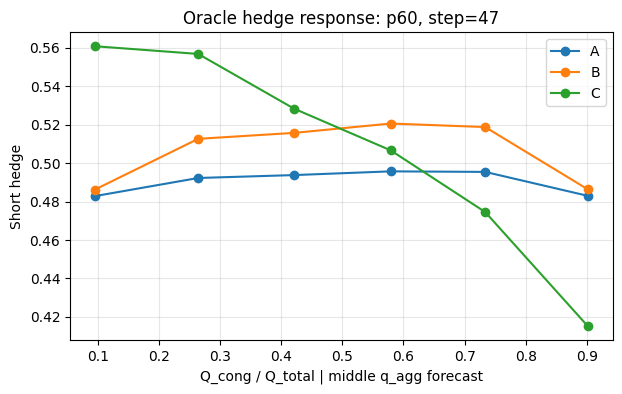

In [7]:

ORACLE_CASE = "p60"
ORACLE_STEP = 47
ORACLE_TRAIN_SAMPLES = 50000
ORACLE_EVAL_SAMPLES = 30000
ORACLE_HEDGE_GRID = np.linspace(0.0, INVENTORY_BOUND, 151)


def make_quantile_bins(values, n_bins):
    values = np.asarray(values, dtype=float).reshape(-1)
    bins = np.unique(np.quantile(values, np.linspace(0.0, 1.0, n_bins + 1)))
    if len(bins) < 3:
        lo, hi = float(np.min(values)), float(np.max(values))
        bins = np.linspace(lo, hi + 1e-12, 3)
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def feature_cell_ids(features, bins_list):
    ids = np.zeros(len(features[0]), dtype=int)
    multiplier = 1
    for values, bins in zip(features, bins_list):
        digitized = np.clip(np.digitize(values, bins) - 1, 0, len(bins) - 2)
        ids += multiplier * digitized
        multiplier *= max(len(bins) - 1, 1)
    return ids


def best_short_for_paths(payoff, d_forward, hedge_grid):
    best_h = 0.0
    best_es = -np.inf
    for h in hedge_grid:
        gains = payoff - h * d_forward
        es = expected_shortfall(gains, 0.05)
        if es > best_es:
            best_h = float(h)
            best_es = float(es)
    return best_h, best_es


def fit_binned_oracle(features, world, hedge_grid, *, bins_per_dim, min_cell_samples=80):
    features = [np.asarray(f, dtype=float).reshape(-1) for f in features]
    bins_list = [make_quantile_bins(f, bins_per_dim) for f in features]
    cell_ids = feature_cell_ids(features, bins_list)
    payoff = np.asarray(world.details.payoff, dtype=float).reshape(-1)
    d_forward = np.asarray(world.data.market.hedges, dtype=float)[:, ORACLE_STEP, 0]
    fallback_h, _ = best_short_for_paths(payoff, d_forward, hedge_grid)
    policy = {}
    for cell_id in np.unique(cell_ids):
        mask = cell_ids == cell_id
        if np.sum(mask) < min_cell_samples:
            continue
        policy[int(cell_id)], _ = best_short_for_paths(payoff[mask], d_forward[mask], hedge_grid)
    return {"bins": bins_list, "policy": policy, "fallback": fallback_h}


def apply_binned_oracle(model, features):
    features = [np.asarray(f, dtype=float).reshape(-1) for f in features]
    cell_ids = feature_cell_ids(features, model["bins"])
    return np.array([model["policy"].get(int(cell_id), model["fallback"]) for cell_id in cell_ids])


def oracle_features(world, model, step):
    details = world.details
    if model == "A":
        return [np.asarray(details.q_agg_forecast)[:, step]]
    if model == "B":
        return [
            np.asarray(details.q_agg_forecast)[:, step],
            np.asarray(details.q_cross_sectional_dispersion_forecast)[:, step],
        ]
    if model == "C":
        return [
            np.asarray(details.q_cong_forecast)[:, step],
            np.asarray(details.q_unc_forecast)[:, step],
        ]
    raise ValueError(model)


def oracle_summary_row(label, information_set, world, short_hedge, baseline_es=None):
    payoff = np.asarray(world.details.payoff, dtype=float).reshape(-1)
    d_forward = np.asarray(world.data.market.hedges, dtype=float)[:, ORACLE_STEP, 0]
    gains = payoff - np.asarray(short_hedge, dtype=float).reshape(-1) * d_forward
    es5 = expected_shortfall(gains, 0.05)
    return {
        "model": label,
        "information_set": information_set,
        "mean_pnl": float(np.mean(gains)),
        "es_5pct": es5,
        "std_pnl": float(np.std(gains)),
        "mean_short_hedge": float(np.mean(short_hedge)),
        "std_short_hedge": float(np.std(short_hedge)),
        "q05_short_hedge": float(np.quantile(short_hedge, 0.05)),
        "q95_short_hedge": float(np.quantile(short_hedge, 0.95)),
        "es_improvement_vs_A": np.nan if baseline_es is None else float(es5 - baseline_es),
    }

l_max = L_MAX_BY_CASE[ORACLE_CASE]
train_world_oracle = build_spatial_volume_risk_world(ORACLE_TRAIN_SAMPLES, 2312414312, feature_model_type="C", l_max=l_max)
eval_world_oracle = build_spatial_volume_risk_world(ORACLE_EVAL_SAMPLES, 202604081, feature_model_type="C", l_max=l_max)

oracle_models = {
    "A": fit_binned_oracle(oracle_features(train_world_oracle, "A", ORACLE_STEP), train_world_oracle, ORACLE_HEDGE_GRID, bins_per_dim=25),
    "B": fit_binned_oracle(oracle_features(train_world_oracle, "B", ORACLE_STEP), train_world_oracle, ORACLE_HEDGE_GRID, bins_per_dim=8),
    "C": fit_binned_oracle(oracle_features(train_world_oracle, "C", ORACLE_STEP), train_world_oracle, ORACLE_HEDGE_GRID, bins_per_dim=10),
}
short_oracle = {
    model: apply_binned_oracle(oracle_models[model], oracle_features(eval_world_oracle, model, ORACLE_STEP))
    for model in ["A", "B", "C"]
}

static_h, _ = best_short_for_paths(
    np.asarray(train_world_oracle.details.payoff),
    np.asarray(train_world_oracle.data.market.hedges)[:, ORACLE_STEP, 0],
    ORACLE_HEDGE_GRID,
)
short_static = np.full(eval_world_oracle.nSamples, static_h)

a_row = oracle_summary_row("A oracle", "q_agg_forecast", eval_world_oracle, short_oracle["A"])
a_es = a_row["es_5pct"]
oracle_summary = pd.DataFrame([
    oracle_summary_row("static", "constant short hedge", eval_world_oracle, short_static, baseline_es=a_es),
    a_row | {"es_improvement_vs_A": 0.0},
    oracle_summary_row("B oracle", "q_agg_forecast + dispersion", eval_world_oracle, short_oracle["B"], baseline_es=a_es),
    oracle_summary_row("C oracle", "site-derived q_cong_forecast + q_unc_forecast", eval_world_oracle, short_oracle["C"], baseline_es=a_es),
])
display(oracle_summary)

arr = mechanism_arrays(eval_world_oracle)
same_qagg = middle_fraction_mask(np.asarray(eval_world_oracle.details.q_agg_forecast)[:, ORACLE_STEP], fraction=0.30)
x = arr["q_cong_share"][same_qagg]
oracle_slope_rows = []
for model in ["A", "B", "C"]:
    oracle_slope_rows.append({
        "model": model,
        "short_slope_vs_Qcong_share": linear_slope(x, short_oracle[model][same_qagg]),
    })
oracle_slope_summary = pd.DataFrame(oracle_slope_rows)
display(oracle_slope_summary)

oracle_passed = bool(
    (oracle_summary.loc[oracle_summary["model"] == "C oracle", "es_improvement_vs_A"].iloc[0] > 0.0)
    and (
        oracle_slope_summary.loc[oracle_slope_summary["model"] == "C", "short_slope_vs_Qcong_share"].iloc[0]
        < oracle_slope_summary.loc[oracle_slope_summary["model"] == "A", "short_slope_vs_Qcong_share"].iloc[0]
    )
)
print(f"Oracle gate passed: {oracle_passed}")

bins = np.unique(np.quantile(x, np.linspace(0.0, 1.0, 7)))
centers = 0.5 * (bins[:-1] + bins[1:])
fig, ax = plt.subplots(figsize=(7, 4))
for model in ["A", "B", "C"]:
    ax.plot(centers, binned_mean(x, short_oracle[model][same_qagg], bins), marker="o", label=model)
ax.set_title(f"Oracle hedge response: {ORACLE_CASE}, step={ORACLE_STEP}")
ax.set_xlabel("Q_cong / Q_total | middle q_agg forecast")
ax.set_ylabel("Short hedge")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


### Neural Training

Use `TRAINING_MODE = "debug_C"` for a quick C-only run. Switch to `TRAINING_MODE = "abc_5_seed"` for the full matched-seed comparison.


Training mode: abc_5_seed; plan: {'p60': ['A', 'B', 'C']}; seeds: [2312414312, 202604071, 202604081, 202604091, 202604101]

=== Training case: p60 | L_max=0.2964767217636108 ===
Initializing training at 2026-05-14 09:41:40: gym with 10.52K trainable weights compiled. Took 2s
Agent is using 8641 weights: 8641 for the main agent per step.
 Features available per time step:     action, cost, delta, forward_price, pnl, time_left and wind_info
 Features used per time step:          forward_price, time_left and wind_info
Monetary utility cvar@19 is using 941 weights
 Features available: cost, forward_price, time_left and wind_info
 Features used:      forward_price, time_left and wind_info
Training monitor initialized. Took 0s
                                                                                                                                                                                                         


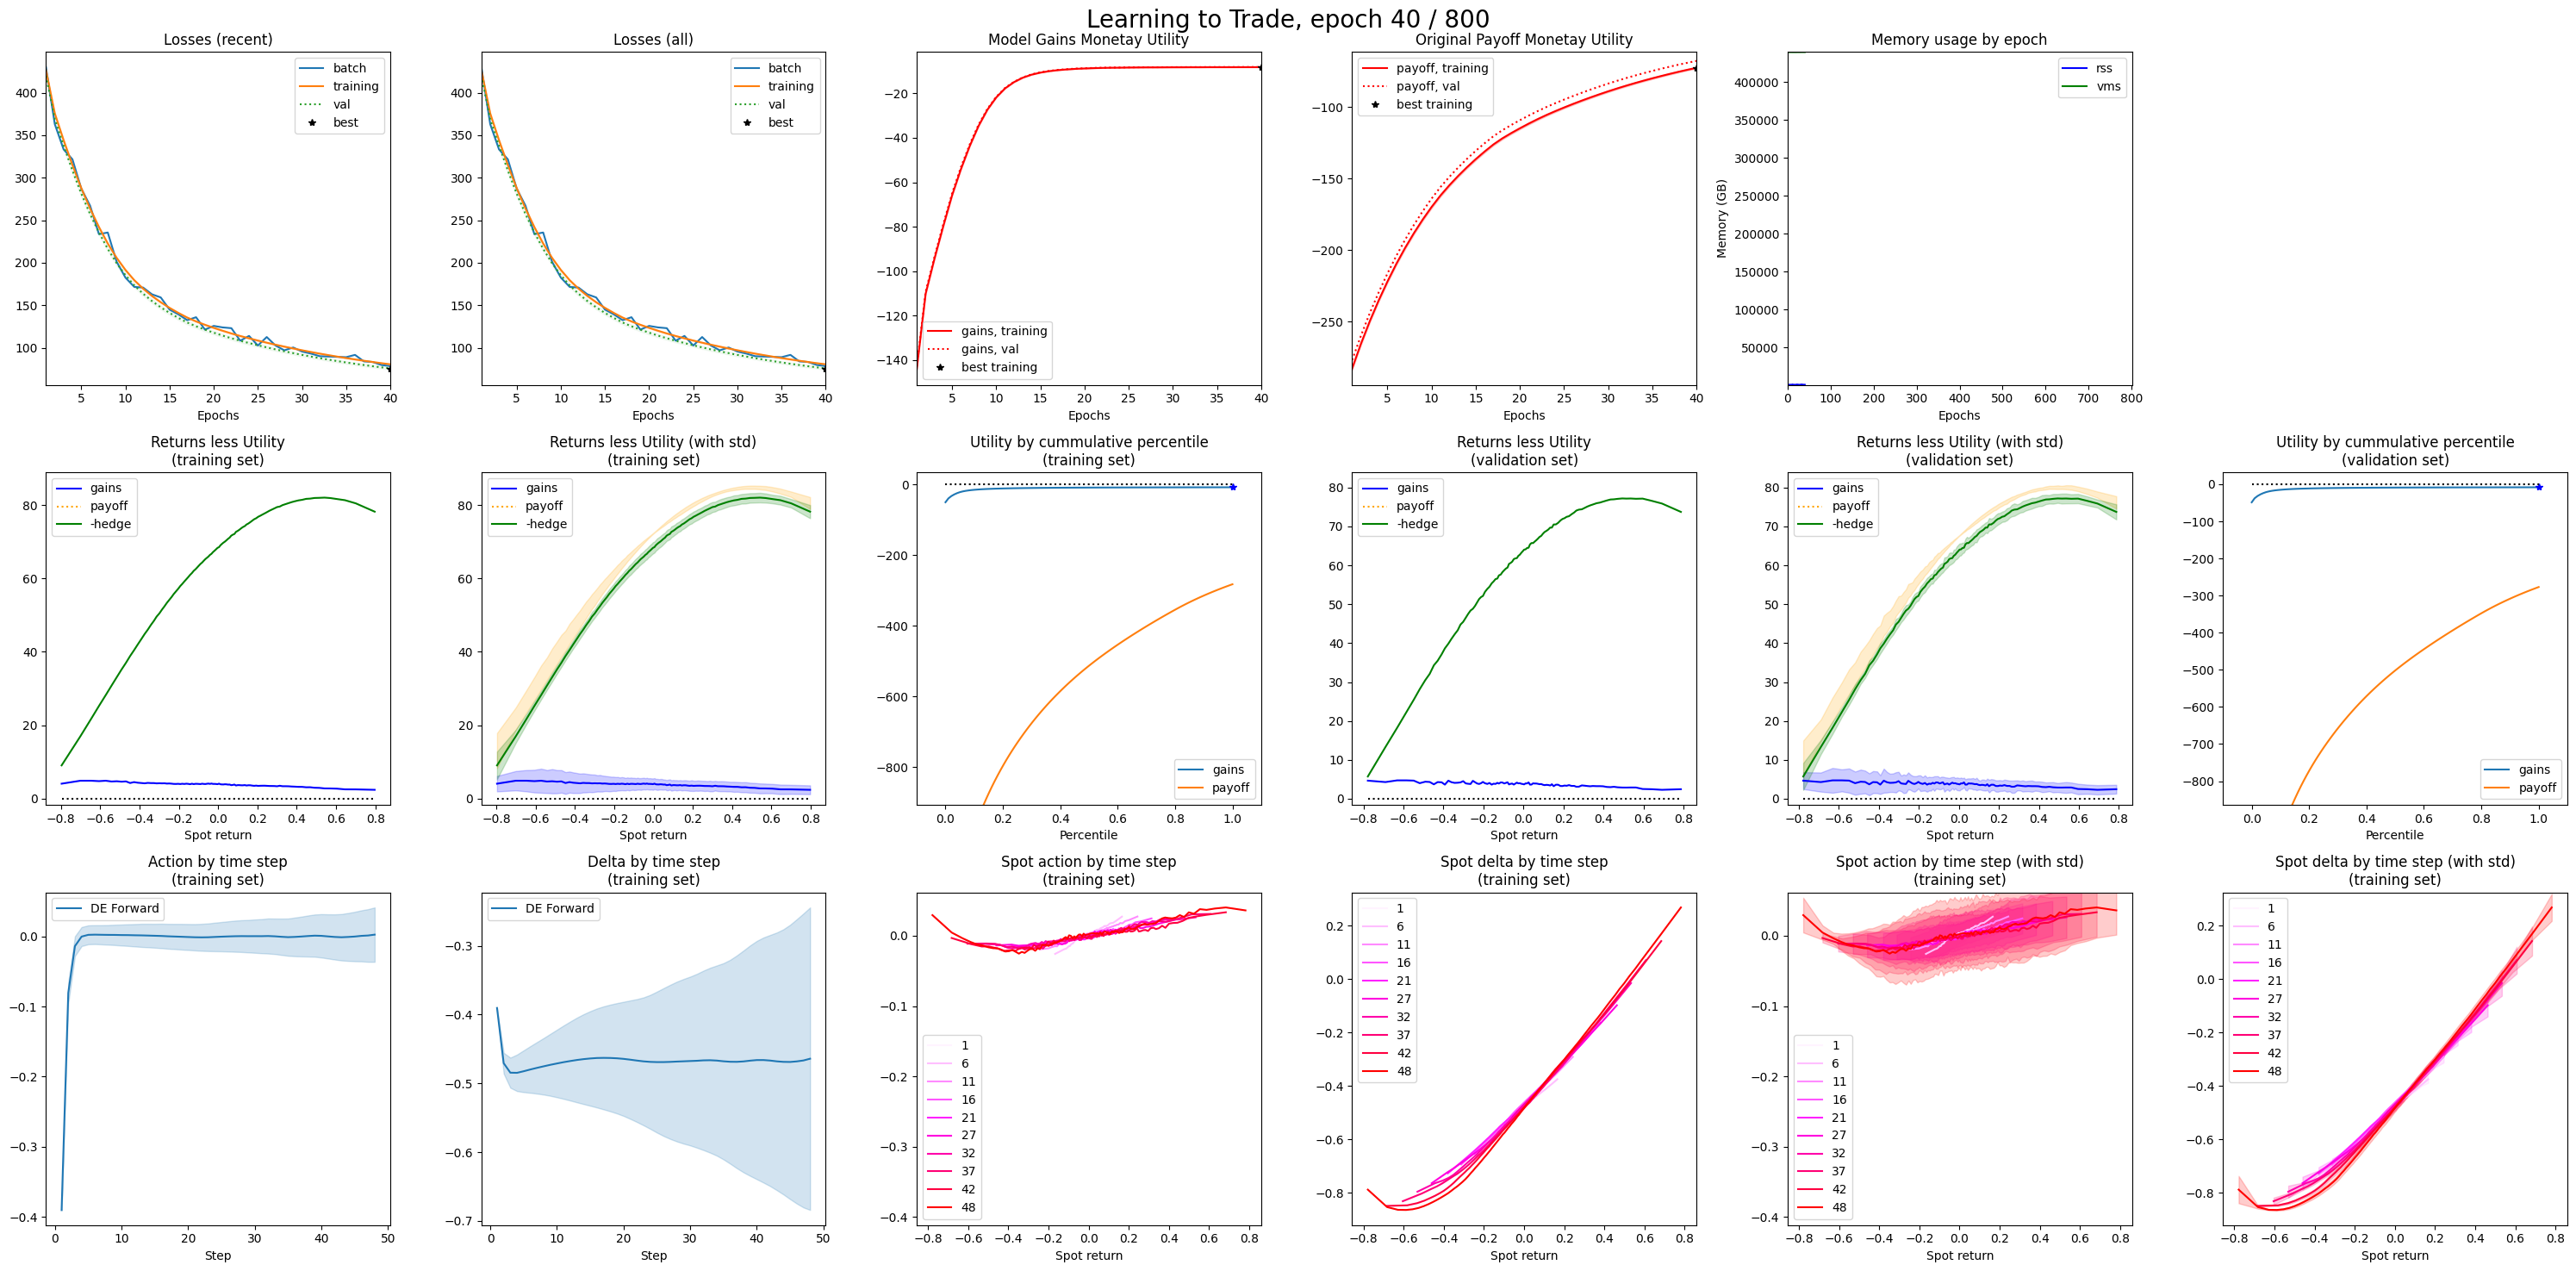

Training 40/800 epochs; 10.52K weights; 100000 samples; 10000 validation samples batch size 2000 | initial loss 534.69 (3.19049), training 80.585 (0.480917), best 75.7203 (1.43096), batch 78.4622, val 75.7203 (1.43096); best epoch 40 | memory used: rss 744.062M, vms 439632M | time elapsed 5:54; time per epoch 8s; estimated time remaining 1:52:07 | current time: 2026-05-14 09:47:50, estimated end time: 2026-05-14 11:39:57                         
 Status: Aborted.
 Weights set to best validation epoch: 40
 Time: 2026-05-14 09:47:51
Training terminated. Total time taken 6:10
Case p60, Model A, seed 2312414312, curtailment frequency 0.400
Bound diagnostics: {'max_abs_action': 0.3901522159576416, 'q95_abs_action': 0.08099870085716242, 'q99_abs_action': 0.3901522159576416, 'action_bound_hit_rate': 0.0, 'max_abs_position': 0.8789046406745911, 'q95_abs_position': 0.7207659155130386, 'q99_abs_position': 0.8308525675535202, 'inventory_bound_hit_rate': 0.0}
Collapse diagnostics: {'model': 'A', '

KeyboardInterrupt: 

In [11]:

TRAINING_MODE = "abc_5_seed"  # options: "debug_C", "abc_5_seed"
TRAINING_CASES = ["p60"]
TRAINING_SEEDS_5 = [2312414312, 202604071, 202604081, 202604091, 202604101]
TRAINING_SEEDS_DEBUG = [2312414312]
REQUIRE_PREFLIGHT_AND_ORACLE = True

# if REQUIRE_PREFLIGHT_AND_ORACLE and not (globals().get("preflight_passed", False) and globals().get("oracle_passed", False)):
#     raise RuntimeError("Run the preflight and oracle gate first; at least one gate did not pass.")
# Turn on if you want to require preflight and oracle gate to pass before neural training.

if TRAINING_MODE == "debug_C":
    training_plan = {case: ["C"] for case in TRAINING_CASES}
    seeds = TRAINING_SEEDS_DEBUG
    train_samples = 100000
    val_samples = 10000
    eval_samples = 20000
    train_epochs = 800
    batch_size = 2000
    network_width = 64
    early_stopping_start = 150
    early_stopping_patience = 50
elif TRAINING_MODE == "abc_5_seed":
    training_plan = {case: ["A", "B", "C"] for case in TRAINING_CASES}
    seeds = TRAINING_SEEDS_5
    train_samples = 100000
    val_samples = 10000
    eval_samples = 20000
    train_epochs = 800
    batch_size = 2000
    network_width = 64
    early_stopping_start = 150
    early_stopping_patience = 50
else:
    raise ValueError(TRAINING_MODE)

features = ["time_left", "forward_price", "wind_info"]
initial_learning_rate = 2e-5
decay_steps = 8000
decay_rate = 0.2
conditional_cvar_objective = True


def execute_target_position_policy(target_positions, *, trade_bound=TRADE_BOUND, inventory_bound=INVENTORY_BOUND):
    target_positions = np.asarray(target_positions, dtype=float)
    if target_positions.ndim == 1:
        target_positions = np.full((target_positions.shape[0], 1), target_positions)
    actions = np.zeros_like(target_positions)
    positions = np.zeros_like(target_positions)
    current = np.zeros(target_positions.shape[0], dtype=float)
    for t in range(target_positions.shape[1]):
        trade = np.clip(target_positions[:, t] - current, -trade_bound, trade_bound)
        proposed = current + trade
        clipped = np.clip(proposed, -inventory_bound, inventory_bound)
        actions[:, t] = clipped - current
        positions[:, t] = clipped
        current = clipped
    return positions, actions


def target_short_hedge_gains(world, target_short_hedges):
    target_short_hedges = np.asarray(target_short_hedges, dtype=float)
    if target_short_hedges.ndim == 0:
        target_short_hedges = np.full((world.nSamples, world.nSteps), float(target_short_hedges))
    if target_short_hedges.ndim == 1:
        target_short_hedges = np.repeat(target_short_hedges[:, None], world.nSteps, axis=1)
    target_positions = -target_short_hedges
    positions, actions = execute_target_position_policy(target_positions)
    hedges = np.asarray(world.data.market.hedges)[:, :, 0]
    costs = np.sum(np.abs(actions) * np.asarray(world.data.market.cost)[:, :, 0], axis=1)
    gains = np.asarray(world.details.payoff).reshape(-1) + np.sum(actions * hedges, axis=1)
    if getattr(world, "use_transaction_cost", False):
        gains = gains - costs
    else:
        costs = np.zeros_like(gains)
    return gains, actions, costs, positions


def bound_diagnostics(actions):
    actions = np.asarray(actions, dtype=float)
    if actions.ndim == 3:
        actions = actions[:, :, 0]
    positions = np.cumsum(actions, axis=1)
    abs_actions = np.abs(actions).reshape(-1)
    abs_positions = np.abs(positions).reshape(-1)
    return {
        "max_abs_action": float(np.max(abs_actions)),
        "q95_abs_action": float(np.quantile(abs_actions, 0.95)),
        "q99_abs_action": float(np.quantile(abs_actions, 0.99)),
        "action_bound_hit_rate": float(np.mean(abs_actions >= 0.99 * TRADE_BOUND)),
        "max_abs_position": float(np.max(abs_positions)),
        "q95_abs_position": float(np.quantile(abs_positions, 0.95)),
        "q99_abs_position": float(np.quantile(abs_positions, 0.99)),
        "inventory_bound_hit_rate": float(np.mean(abs_positions >= 0.99 * INVENTORY_BOUND)),
    }


def collapse_diagnostics(result, world, model_label, decision_step=47):
    actions = np.asarray(result["actions"], dtype=float)[:, :, 0]
    positions = np.cumsum(actions, axis=1)
    final_short = -positions[:, -1]
    abs_actions_by_path = np.sum(np.abs(actions), axis=1)
    first_trade_share = np.divide(
        np.abs(actions[:, 0]),
        abs_actions_by_path,
        out=np.zeros(actions.shape[0]),
        where=abs_actions_by_path > 1e-12,
    )
    arr = mechanism_arrays(world)
    same_qagg = middle_fraction_mask(np.asarray(world.details.q_agg_forecast)[:, decision_step], fraction=0.30)
    short_at_step = -positions[:, min(decision_step, positions.shape[1] - 1)]
    return {
        "model": model_label,
        "std_final_short_hedge": float(np.std(final_short)),
        "q05_final_short_hedge": float(np.quantile(final_short, 0.05)),
        "q95_final_short_hedge": float(np.quantile(final_short, 0.95)),
        "first_trade_abs_share": float(np.mean(first_trade_share)),
        "q95_abs_position": float(np.quantile(np.abs(positions).reshape(-1), 0.95)),
        "short_slope_vs_Qcong_share": linear_slope(arr["q_cong_share"][same_qagg], short_at_step[same_qagg]),
    }


def configure_training(gym_cfg, trainer_cfg):
    gym_cfg.objective.utility = "cvar"
    gym_cfg.objective.lmbda = 19
    gym_cfg.agent.network.depth = 3
    gym_cfg.agent.network.width = network_width
    gym_cfg.agent.network.activation = "selu"
    gym_cfg.agent.use_gru = False
    gym_cfg.agent.features = features
    gym_cfg.agent.state.features = features
    gym_cfg.agent.init_delta.active = False
    gym_cfg.agent.init_delta.features = features
    if conditional_cvar_objective:
        gym_cfg.objective.y.features = features
    trainer_cfg.train.optimizer.learning_rate = tf.keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=initial_learning_rate,
        decay_steps=decay_steps,
        decay_rate=decay_rate,
        staircase=True,
    )
    trainer_cfg.train.optimizer.name = "adam"
    trainer_cfg.train.batch_size = batch_size
    trainer_cfg.train.epochs = train_epochs
    trainer_cfg.train.early_stopping.active = True
    trainer_cfg.train.early_stopping.start_epoch = early_stopping_start
    trainer_cfg.train.early_stopping.patience = early_stopping_patience
    trainer_cfg.train.early_stopping.min_delta = 1e-4
    trainer_cfg.train.tf_verbose = 0
    trainer_cfg.caching.mode = "off"
    trainer_cfg.output_level = "all"
    trainer_cfg.visual.epoch_refresh = 10

case_results = {case: {model: {} for model in models} for case, models in training_plan.items()}
case_eval_worlds = {case: {model: {} for model in models} for case, models in training_plan.items()}
case_benchmark_results = {case: {model: {} for model in models} for case, models in training_plan.items()}
case_bound_diagnostics = {case: {model: {} for model in models} for case, models in training_plan.items()}
case_collapse_diagnostics = {case: {model: {} for model in models} for case, models in training_plan.items()}
case_training_summaries = {case: {model: {} for model in models} for case, models in training_plan.items()}
collapse_rows = []

print(f"Training mode: {TRAINING_MODE}; plan: {training_plan}; seeds: {seeds}")

for case_name, model_list in training_plan.items():
    l_max = L_MAX_BY_CASE[case_name]
    print(f"\n=== Training case: {case_name} | L_max={l_max} ===")
    for model in model_list:
        for seed_idx, seed in enumerate(seeds):
            cfg = Config()
            configure_spatial_volume_risk_world(cfg.world, samples=train_samples, seed=seed, feature_model_type=model, l_max=l_max)
            configure_training(cfg.gym, cfg.trainer)
            cfg.gym.tensorflow.seed = seed

            train_world = PPAWorld(cfg.world)
            val_world = train_world.clone(seed=seed + 1009, samples=val_samples)
            eval_world = train_world.clone(seed=seed + 2003, samples=eval_samples)

            static_volume_short = float(np.mean(np.asarray(train_world.details.q_tilde)))
            dynamic_volume_short = np.asarray(eval_world.details.q_agg_forecast)[:, :-1]
            optimized_static_short = float(np.asarray(train_world.get_optimal_static_delta(lmbda=19.0)).reshape(-1)[0])

            static_volume_gains, static_volume_actions, static_volume_costs, static_volume_positions = target_short_hedge_gains(eval_world, static_volume_short)
            dynamic_volume_gains, dynamic_volume_actions, dynamic_volume_costs, dynamic_volume_positions = target_short_hedge_gains(eval_world, dynamic_volume_short)
            optimized_static_gains, optimized_static_actions, optimized_static_costs, optimized_static_positions = target_short_hedge_gains(eval_world, optimized_static_short)

            case_benchmark_results[case_name][model][seed_idx] = {
                "static_volume": {"delta": static_volume_short, "gains": static_volume_gains, "actions": static_volume_actions, "positions": static_volume_positions, "cost": static_volume_costs},
                "dynamic_volume": {"delta": dynamic_volume_short, "gains": dynamic_volume_gains, "actions": dynamic_volume_actions, "positions": dynamic_volume_positions, "cost": dynamic_volume_costs},
                "optimized_static_delta": {"delta": optimized_static_short, "gains": optimized_static_gains, "actions": optimized_static_actions, "positions": optimized_static_positions, "cost": optimized_static_costs},
            }

            gym = VanillaDeepHedgingGym(cfg.gym)
            train_monitor = train(gym=gym, world=train_world, val_world=val_world, config=cfg.trainer)
            result = npCast(gym(eval_world.tf_data))

            case_results[case_name][model][seed_idx] = result
            case_eval_worlds[case_name][model][seed_idx] = eval_world
            case_training_summaries[case_name][model][seed_idx] = train_monitor
            case_bound_diagnostics[case_name][model][seed_idx] = bound_diagnostics(result["actions"])
            diag = collapse_diagnostics(result, eval_world, model)
            diag.update({"case": case_name, "seed": seed})
            case_collapse_diagnostics[case_name][model][seed_idx] = diag
            collapse_rows.append(diag)

            curtailment_frequency = float(np.mean(np.asarray(eval_world.details.q_cong) > l_max))
            print(f"Case {case_name}, Model {model}, seed {seed}, curtailment frequency {curtailment_frequency:.3f}")
            print("Bound diagnostics:", case_bound_diagnostics[case_name][model][seed_idx])
            print("Collapse diagnostics:", diag)
            print_gain_stats(static_volume_gains, "Static delivered-volume hedge")
            print_gain_stats(dynamic_volume_gains, "Dynamic aggregate-volume hedge")
            print_gain_stats(optimized_static_gains, "Optimized static delta hedge (reference)")
            hedged_gains = np.asarray(result["payoff"] + result["pnl"] - result["cost"]).reshape(-1)
            print_gain_stats(hedged_gains, f"Deep hedge {model}")

collapse_diagnostics_summary = pd.DataFrame(collapse_rows)
display(collapse_diagnostics_summary)

active_training_case = next(iter(training_plan))
results = case_results[active_training_case]
eval_worlds = case_eval_worlds[active_training_case]
benchmark_results = case_benchmark_results[active_training_case]
models = training_plan[active_training_case]


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>std_final_short_hedge</th>
      <th>q05_final_short_hedge</th>
      <th>q95_final_short_hedge</th>
      <th>first_trade_abs_share</th>
      <th>q95_abs_position</th>
      <th>short_slope_vs_Qcong_share</th>
      <th>case</th>
      <th>seed</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>C</td>
      <td>0.263238</td>
      <td>-0.01667</td>
      <td>0.83623</td>
      <td>0.254264</td>
      <td>0.718132</td>
      <td>-0.11081</td>
      <td>p60</td>
      <td>2312414312</td>
    </tr>
  </tbody>
</table>
</div>

Training 263/1200 epochs; 11.46K weights; 100000 samples; 10000 validation samples batch size 2000 | initial loss 801.728 (9.91463), training 55.9663 (0.169217), best 54.5211 (0.523968), batch 56.1143, val 54.5396 (0.482619); best epoch 61 | memory used: rss 1217.44M, vms 438474M | time elapsed 37:09; time per epoch 8s; estimated time remaining 2:12:23 | current time: 2026-05-14 09:28:32, estimated end time: 2026-05-14 11:40:56                        
 Status: Aborted.
 Weights set to best validation epoch: 61
 Time: 2026-05-14 09:28:34
Training terminated. Total time taken 37:15
Case p60, Model C, seed 2312414312, curtailment frequency 0.400
Bound diagnostics: {'max_abs_action': 0.38626742362976074, 'q95_abs_action': 0.08000522553920739, 'q99_abs_action': 0.38626742362976074, 'action_bound_hit_rate': 0.0, 'max_abs_position': 0.8911204934120178, 'q95_abs_position': 0.7181318253278731, 'q99_abs_position': 0.8214876705408096, 'inventory_bound_hit_rate': 0.0}
Collapse diagnostics: {'model': 'C', 'std_final_short_hedge': 0.2632382320744924, 'q05_final_short_hedge': -0.01667046546936034, 'q95_final_short_hedge': 0.8362302035093307, 'first_trade_abs_share': 0.2542638036504221, 'q95_abs_position': 0.7181318253278731, 'short_slope_vs_Qcong_share': -0.11080967544162759, 'case': 'p60', 'seed': 2312414312}

Static delivered-volume hedge:
    Mean: -4.440917
    Std Dev: 5.870577
    Variance: 34.463677
    Skewness: -1.856605
    1% ES: -28.952308
    5% ES: -21.996258
    30% ES: -11.737738

Dynamic aggregate-volume hedge:
    Mean: -4.439494
    Std Dev: 3.140245
    Variance: 9.861139
    Skewness: -1.666966
    1% ES: -18.338614
    5% ES: -13.762610
    30% ES: -8.127961

Optimized static delta hedge (reference):
    Mean: -4.439277
    Std Dev: 5.864456
    Variance: 34.391842
    Skewness: -1.823285
    1% ES: -28.447692
    5% ES: -21.947998
    30% ES: -11.752241

Deep hedge C:
    Mean: -4.436186
    Std Dev: 1.835077
    Variance: 3.367509
    Skewness: 0.227177
    1% ES: -9.504686
    5% ES: -8.207530
    30% ES: -6.475704

### Trained Mechanism Plot

After neural training, this plots the learned short hedge against `Q_cong / Q_total`, conditional on similar aggregate forecast. The volume-risk mechanism would show C reducing the short hedge as the congested share rises.


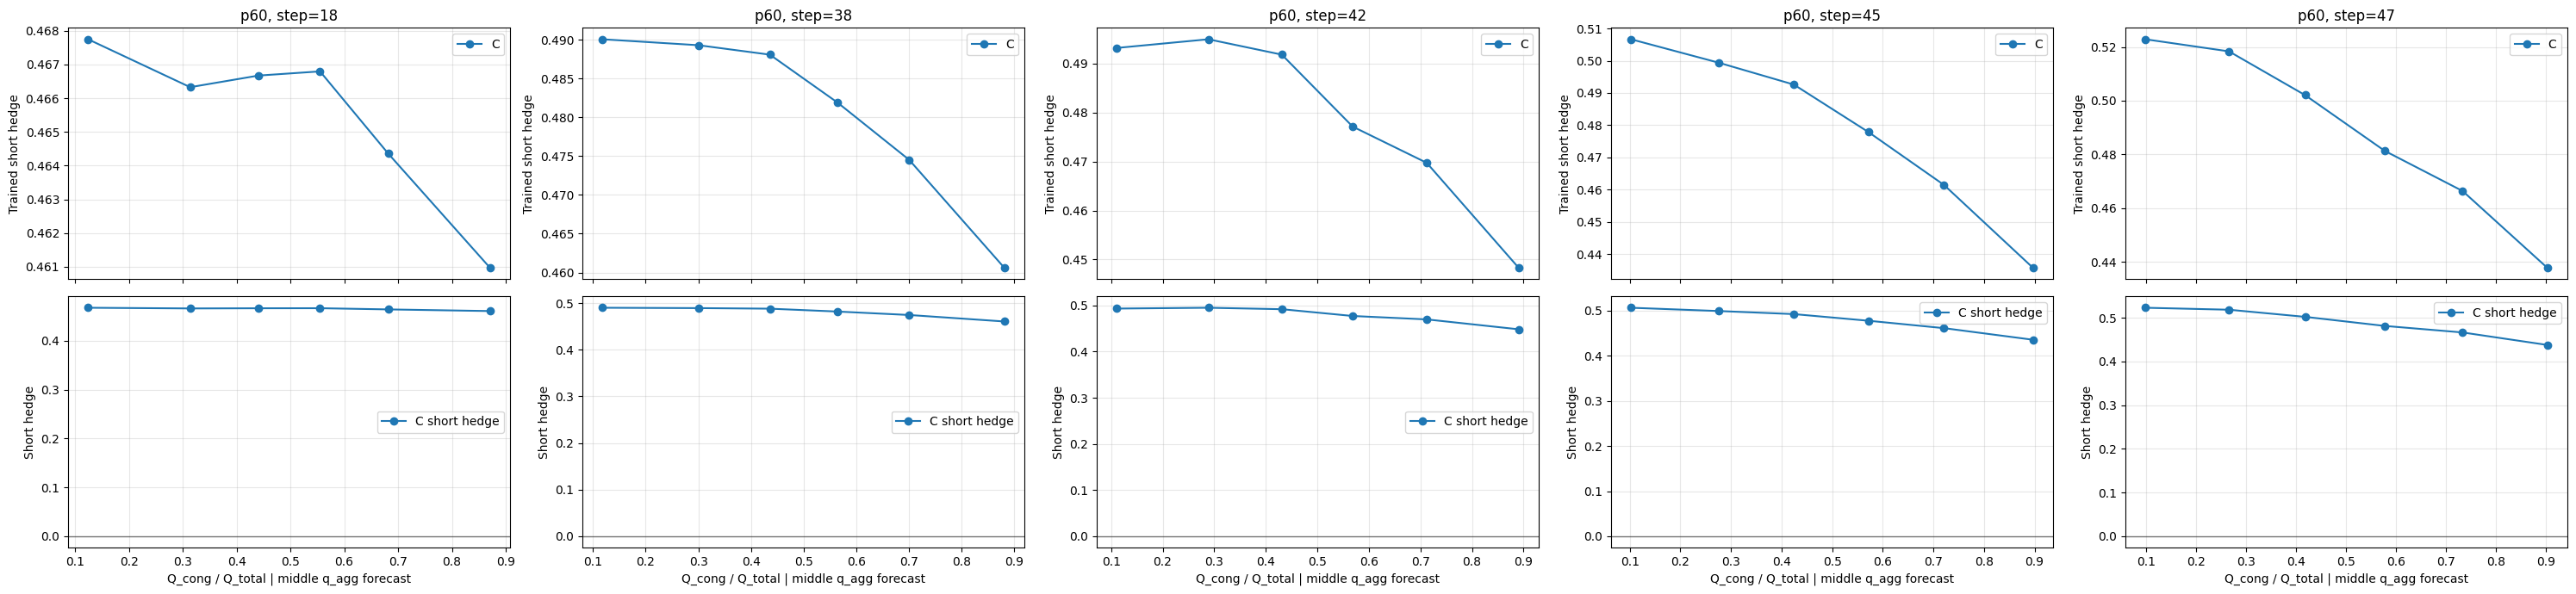

,decision_step,n_paths,delivered_ratio_slope,delivered_volume_slope,C_short_slope
0,18,6000,-0.258541,-0.128935,-0.008310
1,38,6000,-0.295831,-0.152132,-0.039644
2,42,6000,-0.314524,-0.158456,-0.060749
3,45,6000,-0.327489,-0.164784,-0.091574
4,47,6000,-0.337548,-0.170888,-0.110810


In [10]:

TRAINED_MECHANISM_STEPS = [18, 38, 42, 45, 47]
trained_rows = []
fig, axes = plt.subplots(2, len(TRAINED_MECHANISM_STEPS), figsize=(6 * len(TRAINED_MECHANISM_STEPS), 7), sharex="col")
if len(TRAINED_MECHANISM_STEPS) == 1:
    axes = axes.reshape(2, 1)


def trained_short_hedge(result, step):
    actions = np.asarray(result["actions"], dtype=float)[:, :, 0]
    positions = np.cumsum(actions, axis=1)
    return -positions[:, min(step, positions.shape[1] - 1)]

for col, step in enumerate(TRAINED_MECHANISM_STEPS):
    reference_model = models[0]
    x_all = []
    delivered_ratio_all = []
    delivered_volume_all = []
    short_by_model = {model: [] for model in models}

    for seed_idx in sorted(results[reference_model].keys()):
        ref_world = eval_worlds[reference_model][seed_idx]
        arr = mechanism_arrays(ref_world)
        same_qagg = middle_fraction_mask(np.asarray(ref_world.details.q_agg_forecast)[:, step], fraction=0.30)
        x_all.append(arr["q_cong_share"][same_qagg])
        delivered_ratio_all.append(arr["delivered_ratio"][same_qagg])
        delivered_volume_all.append(arr["q_delivered"][same_qagg])
        for model in models:
            short_by_model[model].append(trained_short_hedge(results[model][seed_idx], step)[same_qagg])

    x_all = np.concatenate(x_all)
    delivered_ratio_all = np.concatenate(delivered_ratio_all)
    delivered_volume_all = np.concatenate(delivered_volume_all)
    for model in models:
        short_by_model[model] = np.concatenate(short_by_model[model])

    bins = np.unique(np.quantile(x_all, np.linspace(0.0, 1.0, 7)))
    centers = 0.5 * (bins[:-1] + bins[1:])

    ax = axes[0, col]
    for model in models:
        ax.plot(centers, binned_mean(x_all, short_by_model[model], bins), marker="o", label=model)
    ax.set_title(f"{active_training_case}, step={step}")
    ax.set_ylabel("Trained short hedge")
    ax.grid(alpha=0.3)
    ax.legend()

    ax = axes[1, col]
    if "C" in short_by_model and "A" in short_by_model:
        ax.plot(centers, binned_mean(x_all, short_by_model["C"] - short_by_model["A"], bins), marker="o", label="C - A")
    if "C" in short_by_model and "B" in short_by_model:
        ax.plot(centers, binned_mean(x_all, short_by_model["C"] - short_by_model["B"], bins), marker="o", label="C - B")
    if len(models) == 1:
        ax.plot(centers, binned_mean(x_all, short_by_model[models[0]], bins), marker="o", label=f"{models[0]} short hedge")
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.5)
    ax.set_xlabel("Q_cong / Q_total | middle q_agg forecast")
    ax.set_ylabel("Short hedge difference" if len(models) > 1 else "Short hedge")
    ax.grid(alpha=0.3)
    ax.legend()

    row = {
        "decision_step": step,
        "n_paths": len(x_all),
        "delivered_ratio_slope": linear_slope(x_all, delivered_ratio_all),
        "delivered_volume_slope": linear_slope(x_all, delivered_volume_all),
    }
    for model in models:
        row[f"{model}_short_slope"] = linear_slope(x_all, short_by_model[model])
    if "C" in short_by_model and "A" in short_by_model:
        row["C_minus_A_short_slope"] = linear_slope(x_all, short_by_model["C"] - short_by_model["A"])
    if "C" in short_by_model and "B" in short_by_model:
        row["C_minus_B_short_slope"] = linear_slope(x_all, short_by_model["C"] - short_by_model["B"])
    trained_rows.append(row)

plt.tight_layout()
plt.show()

trained_mechanism_summary = pd.DataFrame(trained_rows)
display(trained_mechanism_summary)


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>decision_step</th>
      <th>n_paths</th>
      <th>delivered_ratio_slope</th>
      <th>delivered_volume_slope</th>
      <th>C_short_slope</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>18</td>
      <td>6000</td>
      <td>-0.258541</td>
      <td>-0.128935</td>
      <td>-0.008310</td>
    </tr>
    <tr>
      <th>1</th>
      <td>38</td>
      <td>6000</td>
      <td>-0.295831</td>
      <td>-0.152132</td>
      <td>-0.039644</td>
    </tr>
    <tr>
      <th>2</th>
      <td>42</td>
      <td>6000</td>
      <td>-0.314524</td>
      <td>-0.158456</td>
      <td>-0.060749</td>
    </tr>
    <tr>
      <th>3</th>
      <td>45</td>
      <td>6000</td>
      <td>-0.327489</td>
      <td>-0.164784</td>
      <td>-0.091574</td>
    </tr>
    <tr>
      <th>4</th>
      <td>47</td>
      <td>6000</td>
      <td>-0.337548</td>
      <td>-0.170888</td>
      <td>-0.110810</td>
    </tr>
  </tbody>
</table>
</div>

### Summarize pooled results with the cell below


In [ ]:
import pandas as pd
from scipy.stats import skew


def expected_shortfall(gains, alpha):
    x = np.asarray(gains).reshape(-1)
    q_alpha = np.quantile(x, alpha)
    tail = x[x <= q_alpha]
    return float(np.mean(tail))


def gain_stats(gains):
    gains_array = np.asarray(gains).reshape(-1)
    return {
        'mean': float(np.mean(gains_array)),
        'variance': float(np.var(gains_array)),
        'skewness': float(skew(gains_array)),
        'es_1pct': expected_shortfall(gains_array, 0.01),
        'es_5pct': expected_shortfall(gains_array, 0.05),
    }


result_cases = case_results if 'case_results' in globals() else {'p70': results}
benchmark_cases = case_benchmark_results if 'case_benchmark_results' in globals() else {'p70': benchmark_results}
positions = ['unhedged', 'static_volume', 'dynamic_volume', 'optimized_static_delta', 'hedged']


def gains_for(case_name, model_key, seed_idx, position):
    r_i = result_cases[case_name][model_key][seed_idx]
    if position == 'hedged':
        return np.asarray(r_i['payoff'] + r_i['pnl'] - r_i['cost']).reshape(-1)
    if position == 'unhedged':
        return np.asarray(r_i['payoff']).reshape(-1)
    if position == 'static_volume':
        return np.asarray(benchmark_cases[case_name][model_key][seed_idx]['static_volume']['gains']).reshape(-1)
    if position == 'dynamic_volume':
        return np.asarray(benchmark_cases[case_name][model_key][seed_idx]['dynamic_volume']['gains']).reshape(-1)
    if position == 'optimized_static_delta':
        return np.asarray(benchmark_cases[case_name][model_key][seed_idx]['optimized_static_delta']['gains']).reshape(-1)
    raise ValueError(position)


per_seed_rows = []
for case_name, case_result in result_cases.items():
    for model_key in case_result.keys():
        for seed_idx in sorted(case_result[model_key].keys()):
            for position in positions:
                row = {
                    'case': case_name,
                    'model': model_key,
                    'seed_run': seed_idx,
                    'position': position,
                }
                row.update(gain_stats(gains_for(case_name, model_key, seed_idx, position)))
                per_seed_rows.append(row)

per_seed_validation_summary = pd.DataFrame(per_seed_rows)
metric_cols = ['mean', 'variance', 'skewness', 'es_1pct', 'es_5pct']
if len(per_seed_validation_summary) > 0:
    per_seed_validation_summary[metric_cols] = per_seed_validation_summary[metric_cols].round(6)

pooled_rows = []
for case_name, case_result in result_cases.items():
    for model_key in case_result.keys():
        for position in positions:
            pooled = np.concatenate([
                gains_for(case_name, model_key, seed_idx, position)
                for seed_idx in sorted(case_result[model_key].keys())
            ])
            row = {
                'case': case_name,
                'model': model_key,
                'position': position,
            }
            row.update(gain_stats(pooled))
            pooled_rows.append(row)

validation_summary = pd.DataFrame(pooled_rows)
if len(validation_summary) > 0:
    validation_summary[metric_cols] = validation_summary[metric_cols].round(6)

incremental_rows = []
for case_name, case_result in result_cases.items():
    if 'C' not in case_result:
        continue
    c_seed_indices = set(case_result['C'].keys())
    comparison_specs = []
    if 'A' in case_result:
        comparison_specs.append(('Model C minus Model A', 'A', 'hedged'))
    if 'B' in case_result:
        comparison_specs.append(('Model C minus Model B', 'B', 'hedged'))
    for seed_idx in sorted(c_seed_indices):
        c_hedged = gains_for(case_name, 'C', seed_idx, 'hedged')
        for label, rhs_model, rhs_position in comparison_specs:
            if seed_idx not in case_result[rhs_model]:
                continue
            rhs = gains_for(case_name, rhs_model, seed_idx, rhs_position)
            incremental_rows.append({
                'case': case_name,
                'comparison': label,
                'seed_run': seed_idx,
                'mean_diff': float(np.mean(c_hedged) - np.mean(rhs)),
                'variance_diff': float(np.var(c_hedged) - np.var(rhs)),
                'es_1pct_diff': expected_shortfall(c_hedged, 0.01) - expected_shortfall(rhs, 0.01),
                'es_5pct_diff': expected_shortfall(c_hedged, 0.05) - expected_shortfall(rhs, 0.05),
            })
        for label, rhs_position in [
            ('Model C minus static volume', 'static_volume'),
            ('Model C minus dynamic volume', 'dynamic_volume'),
            ('Model C minus optimized static delta', 'optimized_static_delta'),
        ]:
            rhs = gains_for(case_name, 'C', seed_idx, rhs_position)
            incremental_rows.append({
                'case': case_name,
                'comparison': label,
                'seed_run': seed_idx,
                'mean_diff': float(np.mean(c_hedged) - np.mean(rhs)),
                'variance_diff': float(np.var(c_hedged) - np.var(rhs)),
                'es_1pct_diff': expected_shortfall(c_hedged, 0.01) - expected_shortfall(rhs, 0.01),
                'es_5pct_diff': expected_shortfall(c_hedged, 0.05) - expected_shortfall(rhs, 0.05),
            })

incremental_summary = pd.DataFrame(incremental_rows)
if len(incremental_summary) > 0:
    incremental_summary[['mean_diff', 'variance_diff', 'es_1pct_diff', 'es_5pct_diff']] = (
        incremental_summary[['mean_diff', 'variance_diff', 'es_1pct_diff', 'es_5pct_diff']].round(6)
    )

print('Per-seed summary')
display(per_seed_validation_summary)
print('Pooled summary')
display(validation_summary)
if len(incremental_summary) > 0:
    print('Incremental comparison summary')
    display(incremental_summary)


In [ ]:
import numpy as np
from scipy.stats import skew

print("Analysis of PnL used in PPA article:\n")
print(f"Mean payoff: {np.mean(r['payoff']):.6f}")
print(f"Min utility: {np.min(r['utility']):.6f}")
print(f"Min unhedged utility: {np.min(r['utility0']):.6f}")
print(f"Mean hedging pnl: {np.mean(r['pnl']):.6f}")  
print(f"Mean cost: {np.mean(r['cost']):.6f}")
print(f"Mean total gains: {np.mean(r['payoff'] + r['pnl'] - r['cost']):.6f}\n")


hedged_gains = r['payoff'] + r['pnl'] - r['cost']
unhedged_gains = r['payoff']

def compute_stats(gains, label):
    print(f"\n{label}:")
    print(f"    Mean:{np.mean(gains):.6f}")
    print(f"    Std Dev: {np.std(gains):.6f}")
    print(f"    Variance: {np.var(gains):.6f}")
    print(f"    Skewness: {skew(gains):.6f}")
    print(f"    1% ES: {np.mean(gains[gains <= np.percentile(gains,1)]):.6f}")
    print(f"    5% ES: {np.mean(gains[gains <= np.percentile(gains, 5)]):.6f}")
    print(f"    30% ES: {np.mean(gains[gains <= np.percentile(gains, 30)]):.6f}")

compute_stats(hedged_gains, "Hedged gains")
compute_stats(unhedged_gains, "Unhedged gains")
compute_stats(static_delta_gains, "static delta hedge")



### Statistical arbitrage test

In [ ]:
test_config2 = Config(config.trainer)
test_config2.train.epochs = 200
test_config2.caching.mode = "off"

test_world_config = Config(config.world)
test_world2 = PPAWorld(test_world_config)

# CRITICAL: Set payoff to zero
test_world2.data.market.payoff[:] = 0.0

# Clear any cached TensorFlow data
if hasattr(test_world2, '_tf_data'):
    delattr(test_world2, '_tf_data')

# Get the tf_data and MANUALLY fix the payoff
tf_data_fixed = test_world2.tf_data
tf_data_fixed['market']['payoff'] = test_world2.data.market.payoff.copy()

# Verify the fix
print(f"Before training - Payoff mean: {np.mean(test_world2.data.market.payoff):.10f}")
print(f"Fixed TF dataset payoff mean: {np.mean(tf_data_fixed['market']['payoff']):.10f}")
print(f"TF dataset payoff is zero? {np.all(tf_data_fixed['market']['payoff'] == 0)}")

test_gym2 = VanillaDeepHedgingGym(config.gym)

# Create a modified world object that returns our fixed tf_data
class FixedWorld:
    def __init__(self, original_world, fixed_tf_data):
        self.original_world = original_world
        self.fixed_tf_data = fixed_tf_data
        self.nSamples = original_world.nSamples
        self.nSteps = original_world.nSteps
        self.sample_weights = original_world.sample_weights
        self.data = original_world.data
        self.details = original_world.details
    
    @property
    def tf_data(self):
        return self.fixed_tf_data
    
    def clone(self, samples):
        return self.original_world.clone(samples=samples)
    
    def __getattr__(self, name):
        # Fallback to original_world for any missing attributes
        return getattr(self.original_world, name)

fixed_world = FixedWorld(test_world2, tf_data_fixed)

# Train with the fixed world
train(gym=test_gym2, world=fixed_world, val_world=test_world2.clone(samples=10000), config=test_config2)

# Evaluate with the fixed data
r_test2 = test_gym2(tf_data_fixed)

print(f"\n After training - Result payoff mean: {np.mean(r_test2['payoff']):.10f}")
print(f"Mean PnL: {np.mean(r_test2['pnl']):.6f}")
print(f"Max |action|: {np.max(np.abs(r_test2['actions'])):.6f}")



In [ ]:
# Additional diagnostics after your existing code
from scipy import stats

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE TEST")
print("="*60)

print(f"\n📊 Detailed PnL Statistics:")
print(f"Mean PnL: {np.mean(r_test2['pnl']):.6f}")
print(f"Std dev of PnL: {np.std(r_test2['pnl']):.6f}")
print(f"Mean absolute PnL: {np.mean(np.abs(r_test2['pnl'])):.6f}")
print(f"Median PnL: {np.median(r_test2['pnl']):.6f}")

# t-test for PnL = 0
t_stat, p_value = stats.ttest_1samp(r_test2['pnl'], 0)
print(f"\n🔬 t-test for H0: mean PnL = 0")
print(f"   t-statistic: {t_stat:.4f}")
print(f"   p-value: {p_value:.6f}")

if p_value < 0.01:
    print("   ⚠️  PnL is statistically significantly different from zero at 1% level")
    print("   This suggests potential statistical arbitrage")
else:
    print("   ✅  PnL is NOT statistically significantly different from zero")
    print("   This is likely just optimization noise - no arbitrage detected")

# Cost analysis
print(f"\n💰 Cost Statistics:")
print(f"Mean cost: {np.mean(r_test2['cost']):.6f}")
print(f"Mean total gain (payoff + pnl - cost): {np.mean(r_test2['payoff'] + r_test2['pnl'] - r_test2['cost']):.6f}")

# Action analysis
print(f"\n📈 Action Statistics:")
print(f"Mean action: {np.mean(r_test2['actions']):.6f}")
print(f"Std dev of actions: {np.std(r_test2['actions']):.6f}")
print(f"% of zero actions: {100 * np.mean(np.abs(r_test2['actions']) < 0.001):.2f}%")



### Original deep hedging code in this file

In [ ]:
print("Deep Hedging AI says hello ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM

from IPython.display import display, Markdown
from cdxbasics.config import Config
# Re-wrap the trainer config before passing it in

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = True
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# In trainer.ipynb, add to your config
# trainer
config.trainer.train.optimizer.name = "adam"
#config.trainer.train.optimizer.learning_rate = 0.001
#config.trainer.train.optimizer.clipvalue = 1.
#config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
# config.trainer.run_eagerly = True
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

display(Markdown("## Deep Hedging in a Black \& Scholes World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
gym = VanillaDeepHedgingGym( config.gym )
print(type(config.trainer))
# create training environment

train( gym=gym, world=world, val_world=val_world, config=Config(config.trainer) )
r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()



#### Comparison to Black & Scholes

See also notebooks/blackscholes for other notebooks. Note that we use medium risk aversion, hence the hedge is not expected to match the risk-neutral hedge. See the sub directory <tt>blackscholes</tt> for experiments approximating the black & scholes solution

In [ ]:
import deephedging.plot_bs_hedge as plot_bs_hedge
plot_bs_hedge.plot_blackscholes( world, gym, config )



## Stochastic Vol
### Trading with two assets

In [ ]:
print("Deep Hedging AI says hello  ... ", end='')
from cdxbasics.config import Config
from deephedging.trainer import train
from deephedging.gym import VanillaDeepHedgingGym
from deephedging.world import SimpleWorld_Spot_ATM
import tensorflow as tf

from IPython.display import display, Markdown

# see print of the config below for numerous options
config = Config()
# world
config.world.samples = 10000
config.world.steps = 20
config.world.black_scholes = False
# gym
config.gym.objective.utility = "cvar"
config.gym.objective.lmbda = 1.
config.gym.agent.network.depth = 3
config.gym.agent.network.activation = "softplus"
# trainer
config.trainer.train.optimizer.name = "adam"
config.trainer.train.optimizer.learning_rate = 0.001
config.trainer.train.optimizer.clipvalue = 1.
config.trainer.train.optimizer.global_clipnorm = 1.
config.trainer.train.batch_size = None
config.trainer.train.epochs = 800
config.trainer.caching.mode = "on"
config.trainer.train.run_eagerly = None
config.trainer.visual.epoch_refresh = 5
config.trainer.visual.confidence_pcnt_lo = 0.25
config.trainer.visual.confidence_pcnt_hi = 0.75

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

# create world
world  = SimpleWorld_Spot_ATM( config.world )
val_world  = world.clone(samples=world.nSamples//10)

# create training environment
tf.debugging.enable_check_numerics()
gym = VanillaDeepHedgingGym( config.gym )

# create training environment
train( gym=gym, world=world, val_world=val_world, config=config.trainer )
r = gym(world.tf_data)
print("Keys of the dictionary returned by the gym: ", r.keys())

print("=========================================")
print("Config usage report")
print("=========================================")
print( config.usage_report() )
config.done()

